In [1]:
#!/usr/bin/env python
# coding: utf-8

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10,10

from scipy.ndimage.interpolation import zoom
import VGG
import gradcamutils
import numpy as np
import os
from PIL import Image
from keras.models import load_model
import cv2

Using TensorFlow backend.


In [2]:
# use this environment flag to change which GPU to use 
os.environ["CUDA_VISIBLE_DEVICES"]= "-1"  # specify which GPU(s) to be used

In [28]:
def createOrRestoreVGGModel(): 
    vgg19 = load_model("MCNN.h5") #load weights

    model = vgg19
    model.summary()

    return model 

In [85]:
mCNN_model = createOrRestoreVGGModel() 

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 224, 224, 3)  0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            (None, 224, 224, 3)  0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 224, 224, 8)  224         input_1[0][0]                    
__________________________________________________________________________________________________
conv2d_6 (Conv2D)               (None, 224, 224, 8)  224         input_2[0][0]                    
__________________________________________________________________________________________________
conv2d_2 (

In [ ]:
#gradCAM = gradcamutils.grad_cam(mCNN_model, [img1, img2], layer_name = 'conv2d_10') #for VGG, here there are parameters to set image width (W) and height (H)
#gradCAMPlus = gradcamutils.grad_cam_plus(mCNN_model, [img1, img2], layer_name = 'conv2d_10')

In [78]:
img_path1 = "/home/rkarim/COVID_CT_Explainer/LA-DNN-for-COVID-19-diagnosis/Imon/CT_Scans/train/covid/2020.03.21.20040691-p18-67-7.png"
img_path2 = "/home/rkarim/COVID_CT_Explainer/LA-DNN-for-COVID-19-diagnosis/Imon/X_ray/train/covid19/paving.jpg"

img1 = Image.open(img_path1)
img2 = Image.open(img_path2)

img1 = np.array(img1.resize((224, 224), Image.ANTIALIAS))
img2 = np.array(img2.resize((224, 224), Image.ANTIALIAS))

img1 = np.expand_dims(img1, axis=0) # image shape is (1, 12, 12, 3)
img2 = np.expand_dims(img2, axis=0) # image shape is (1, 12, 12, 3)

In [90]:
img2.shape

(1, 224, 224, 3)

In [83]:
pred = mCNN_model.predict([img1, img2])
print(pred)

[[0.]]


In [88]:
preds = pred.flatten()
preds

array([0.], dtype=float32)

In [41]:
def remove_ticks_and_labels(ax):
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)

In [242]:
def decisionVisualization(img, imgArr, xaiMethod, vizMethod):
    # Add batch axis and preprocess   

    fig = plt.figure(constrained_layout=False,figsize=[6,3])
    gs1 = fig.add_gridspec(nrows=1, ncols=2, left=1, right=1.8)

    fig_ax1 = fig.add_subplot(gs1[0, 0])
    fig_ax2 = fig.add_subplot(gs1[0, 1])

    gs2 = fig.add_gridspec(nrows=1, ncols=1, left=1.92, right=2.6)

    fig_ax3 = fig.add_subplot(gs2[0, 0])

    fig_ax1.imshow(img, cmap ='gray')
    fig_ax1.set_title("Input radiograph")

    remove_ticks_and_labels(fig_ax1)
        
    if vizMethod == 'Grad-CAM':

        fig_ax2.imshow(imgArr, cmap ='gray')
        fig_ax2.imshow(xaiMethod, alpha=0.45, cmap="jet")
        fig_ax2.set_title(str(vizMethod))
        remove_ticks_and_labels(fig_ax2)

        #x_probs = [0.12, 0.30]
        x_probs = preds
        x_probs = np.asarray(x_probs, dtype=np.float32)
        y_pos = np.array([0, 1])
        y_objects = ('COVID-19','NON-COVID') #Infection type
        y_labels = ['COVID-19','NON-COVID']

        fig_ax3.barh(y_pos, x_probs, color='blue', align='center', alpha=0.3)
        fig_ax3.set_title("Explanations")
    
        for i, v in enumerate(x_probs):
            fig_ax3.text(v - 0.07, i + 0.1 , '{0:.2f}   {1}'.format(v,y_labels[i]))
    
        fig_ax3.set_yticks(y_pos)
        fig_ax3.set_yticklabels(y_objects)
        fig_ax3.invert_yaxis()  # labels read top-to-bottom
        fig_ax3.set_xticks([0.25, 0.5, 0.75])

        fig.savefig('explanation.png')
        
    if vizMethod == 'Grad-CAM++':

        fig_ax2.imshow(imgArr, cmap ='gray')
        fig_ax2.imshow(xaiMethod, alpha=0.45, cmap="jet")
        fig_ax2.set_title(str(vizMethod))
        remove_ticks_and_labels(fig_ax2)

        #x_probs = [0.12, 0.30]
        x_probs = preds
        x_probs = np.asarray(x_probs, dtype=np.float32)
        y_pos = np.array([0, 1])
        y_objects = ('COVID-19','NON-COVID') #Infection type
        y_labels = ['COVID-19','NON-COVID']

        fig_ax3.barh(y_pos, x_probs, color='red', align='center', alpha=0.3)
        fig_ax3.set_title("Explanations")
    
        for i, v in enumerate(x_probs):
            fig_ax3.text(v - 0.07, i + 0.1 , '{0:.2f}   {1}'.format(v,y_labels[i]))
    
        fig_ax3.set_yticks(y_pos)
        fig_ax3.set_yticklabels(y_objects)
        fig_ax3.invert_yaxis()  # labels read top-to-bottom
        fig_ax3.set_xticks([0.25, 0.5, 0.75])

        fig.savefig('explanation.png')

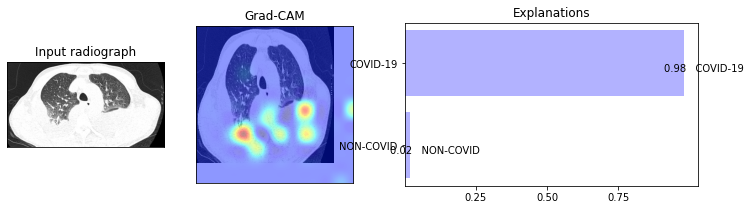

In [243]:
decisionVisualization(img, imgArr, xaiMethod=gradCAM, vizMethod='Grad-CAM')

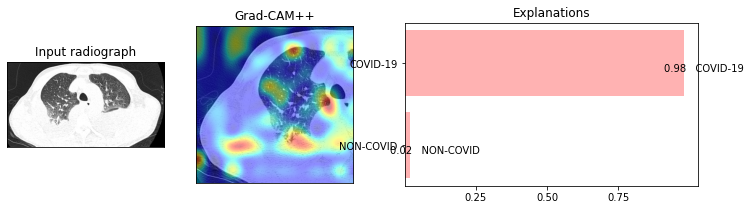

In [244]:
decisionVisualization(img, img, xaiMethod=gradCAMPlus, vizMethod='Grad-CAM++')